# TS1: Generación y Análisis de Señales
Catalina Wynne

## Consigna del ejercicio 1
Sintetizar:

Señal sinusoidal de 2 KHz.

Misma señal amplificada 3 dB y desfasada en π/2.

Misma señal modulada en amplitud por otra señal sinusoidal de frecuencia de 1000 KHz.

Misma señal con efecto de saturación al 75% de su amplitud. Ayuda: ver numpy.clip().

Una señal cuadrada de 4KHz.

Un pulso rectangular de 10ms.

En cada caso indique: período, número de muestras y si se trata de una señal de potencia o energía según corresponda.

## INTRODUCCIÓN
En este trabajo se implementa un generador de señales discretas y se analizan distintas transformaciones sobre una señal senoidal.

Se estudian:
Señales sinusoidales y sus  modificaciones, la modulación en amplitud, la saturación, señales cuadradas y pulsos, además  se clasifican en señales de potencia o energía.

## Definición de señal senoidal
La expresión general es:

                       x(t) = A*sin(2* π*f*t + ϕ) + DC

donde: 

A: amplitud

f: frecuencia (Hz);

ph : fase (ϕ);

DC : valor medio.


## Definición de la función senoidal

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

def mi_funcion_sen(vmax, dc, f, fase, N, fs):
    Ts = 1/fs
    tt = np.arange(N) * Ts
    xx = dc + vmax * np.sin(2*np.pi*f*tt + fase)
    return tt, xx

Se define una función para generar señales senoidales discretas.

El vector de tiempo se construye a partir del período de muestreo Ts = 1/fs.

La señal depende de la amplitud, frecuencia, fase y valor medio.

## Parámetros de Base

In [2]:
f = 2000                # 2 kHz
fs = 40 * f             # buena práctica de muestreo
T = 1 / f
Nciclos = 4
N = int(Nciclos * T * fs)         # cantidad de muestras
Ts = 1/fs

vmax = np.sqrt(2)


Se trabaja con una señal de 2kHz.

Se elige una frecuencia de muestreo 40 veces mayor para representar correctamente la señal.

Se calcula el período y la cantidad de muestras en un período.

## Señal sinusoidal de 2 kHz
Se genera una señal senoidal de frecuencia 2kHz.



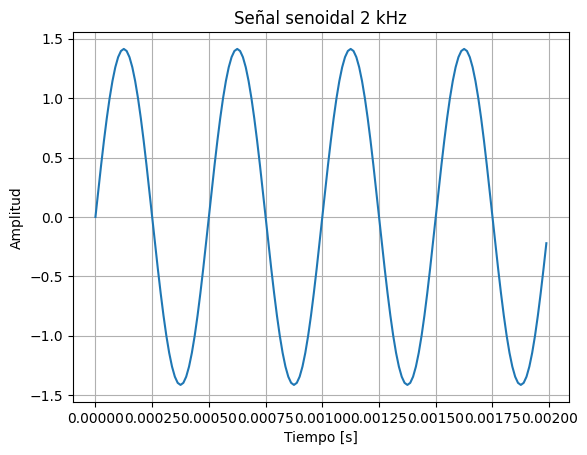

Periodo: 0.0005
Muestras: 160
Potencia: 1.0000000000000002


In [3]:

tt, xx = mi_funcion_sen(vmax, 0, f, 0, N, fs)

plt.plot(tt, xx)
plt.title("Señal senoidal 2 kHz")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid()
plt.show()

potencia = np.mean(xx**2)

print("Periodo:", T)
print("Muestras:", N)
print("Potencia:", potencia)


Se elige que la amplitud sea $\sqrt(2)$ para que la potencia sea 1.
La potencia se calcula como:

                          P = 1/N ∑ x^2 [n]

Se observa una señal senoidal periódica de 2kHz correctamente muestreada. 

La forma es suave debido a la alta frecuencia de muestreo.

La potencia obtenida es aproximadamente 1, lo cual coincide con la teoría para una señal de amplitud como se menciona anteriormente.

Al ser periódica, se trata de una señal de potencia.

## Señal amplificada y desfasada

Se amplifica la señal de 3 dB y se aplica un desfase de π/2.
Manteniendo la forma de la señal pero cambiando su posición y amplitud.

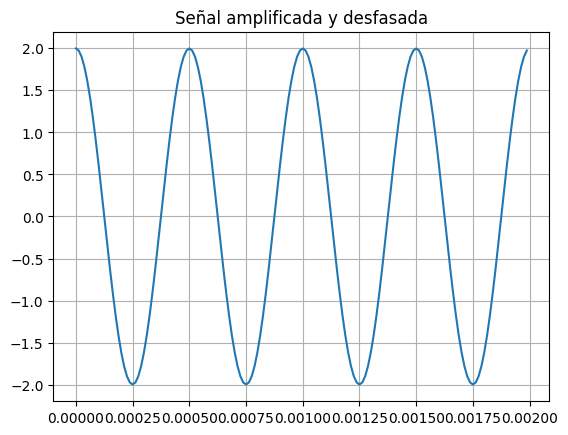

Periodo: 0.0005
Muestras: 160
Potencia: 1.9952623149688804


In [4]:
vmax2 = vmax * 10**(3/20)

tt, x2 = mi_funcion_sen(vmax2, 0, f, np.pi/2, N, fs)

plt.plot(tt, x2)
plt.title("Señal amplificada y desfasada")
plt.grid()
plt.show()

print("Periodo:", T)
print("Muestras:", N)
print("Potencia:", np.mean(x2**2))

La señal mantiene la misma frecuencia pero cambió su amplitud y su fase. 

El desfase de π/2 produce un corrimiento en tiempo.

La potencia aumenta respecto al caso anterior, esto se debe a la amplificación de 3dB.

Es una señal de potencia.

## Señal modulada en amplitud
Se realiza una modulación en amplitud utilizando una señal portadora de alta frecuencia (1 MHz) y una señal moduladora de 2kHz.

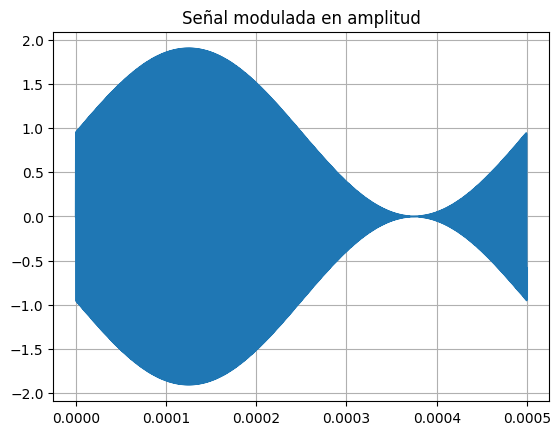

Periodo: 0.0005
Muestras: 5000
Potencia: 0.7499999999999973


In [5]:
fm = 2000
fc = 1000000
fs_mod = 10 * fc
T_mod = 1 / fm
N_mod = int(T_mod * fs_mod)

tt, xm = mi_funcion_sen(vmax, 0, fm, 0, N_mod, fs_mod)
tt, xc = mi_funcion_sen(vmax, 0, fc, 0, N_mod, fs_mod)

x_mod = (1 + xm/vmax) * (xc/vmax)

plt.plot(tt, x_mod)
plt.title("Señal modulada en amplitud")
plt.grid()
plt.show()

print("Periodo:", T_mod)
print("Muestras:", N_mod)
print("Potencia:", np.mean(x_mod**2))

Se observa una señal de alta frecuencia (portadora) cuya amplitud varia con una señal más lenta (moduladora).
Se normaliza la señal moduladora y portadora para evitar sobremodulación, asegurando que la envolvente sea siempre positiva.

La envolvente de la señal corresponde a la señal de 2kHz.

Aparecen bandas laterales en frecuencia.

Es una señal de potencia.

## Señal con saturación
Se limita la amplitud al 75% usando la función clip.

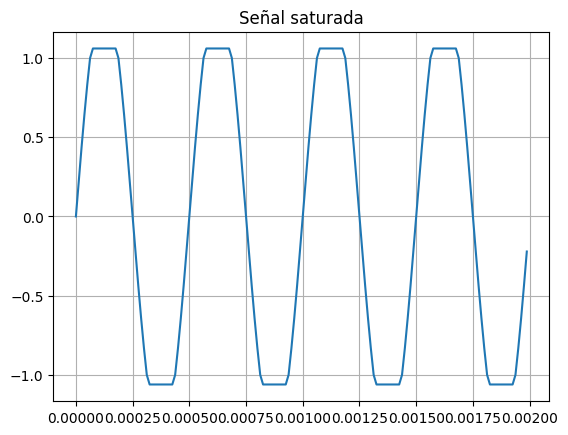

Periodo: 0.0005
Muestras: 160
Potencia: 0.7405624242662481


In [6]:
tt, xx = mi_funcion_sen (vmax, 0, f, 0, N, fs)
limite = 0.75 * vmax
x_clip = np.clip(xx, -limite, limite)

plt.plot(tt, x_clip)
plt.title("Señal saturada")
plt.grid()
plt.show()

print("Periodo:", T)
print("Muestras:", N)
print("Potencia:", np.mean(x_clip**2))

Se aplica un recorte a la señal:

Se limita la amplitud al 75%.

Los picos quedan "aplanados".

Esto introduce distorsión y reduce la potencia.

Es una señal de potencia.



## Señal cuadrada de 4 kHz 
Se genera una señal cuadrada utilizando la función square.

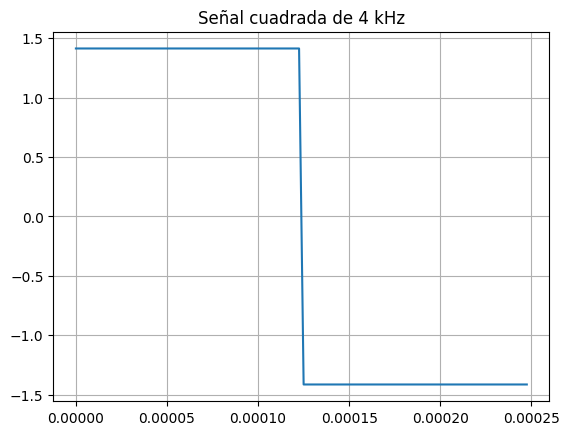

Periodo: 0.00025
Muestras: 100
Potencia: 2.0000000000000004


In [7]:
f_sq = 4000
fs_sq = 100 * f_sq
T_sq = 1/f_sq
N_sq = int(T_sq * fs_sq)

tt_sq = np.arange(N_sq)/fs_sq
x_sq = vmax * signal.square(2*np.pi*f_sq*tt_sq)

plt.plot(tt_sq, x_sq)
plt.title("Señal cuadrada de 4 kHz")
plt.grid()
plt.show()

print("Periodo:", T_sq)
print("Muestras:", N_sq)
print("Potencia:", np.mean(x_sq**2))


A diferencia de la senoidal esta señal tiene cambios bruscos y contiene múltiples armónicos. También, requiere de una mayor frecuencia de muestreo debido a la presencia de armónicos de alta frecuencia.

Es una señal periódica de potencia.

Al mantenerse en valores extremos, su potencia es mayor.




## Pulso rectangular de 10ms
Se genera un pulso de duración finita.

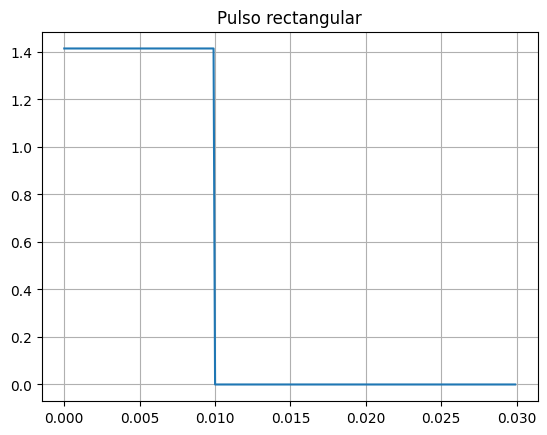

Muestras: 300
Energía: 0.020000000000000007


In [8]:
Tpulso = 0.01
fs_p = 10000
N_p = 300

tt_p = np.arange(N_p)/fs_p
pulso = np.zeros(N_p)

Np_activo = int(Tpulso * fs_p)
pulso[:Np_activo] = vmax

plt.plot(tt_p, pulso)
plt.title("Pulso rectangular")
plt.grid()
plt.show()

energia = np.sum(pulso**2) * (1/fs_p)

print("Muestras:", N_p)
print("Energía:", energia)

La señal solo existe durante un intervalo finito de tiempo.
Luego se mantiene en cero.

Por esta razón es una señal de energía, ya que, su duración es limitada y su potencia media tiende a cero.



## Conclusiones
En este trabajo se implementaron distintas señales discretas a partir de una señal senoidal base.

Se observó cómo modificaciones como la amplificación, el desfase, la modulación y la saturación afectan la forma de la señal.

En particular, la modulación introduce nuevas componentes en frecuencia, mientras que la saturación genera distorsión.

Además, se analizó una señal cuadrada, la cual contiene múltiples armónicos, lo que la hace más susceptible a problemas de muestreo.

Por último, se trabajó con un pulso rectangular, identificándolo como una señal de energía debido a su duración finita.

Este trabajo permitió comprender mejor el comportamiento de señales en tiempo discreto y la importancia de los parámetros de muestreo.

## Consigna Ejercicio 2
Dado h[n] = δ[n] - δ[n - 4], encontrar y[n] = x[n] * h[n] para cada una de las siguientes x[n]:

a) x[n] = cos(ω₀.n. TS). Expresar la respuesta como un único coseno de la forma A cos(ω₀. n . TS + φ).

b) x[n] = (1/2)ⁿ u[n].

c) x[n] = u[n + 1] - u[n - 2].

In [16]:
from IPython.display import IFrame

url_pdf = "https://raw.githubusercontent.com/CATALINAWYNNE/Repositorio-APS/main/TS.pdf"
visor_google = f"https://docs.google.com/gview?url={url_pdf}&embedded=true"

IFrame(visor_google, width=1000, height=800)

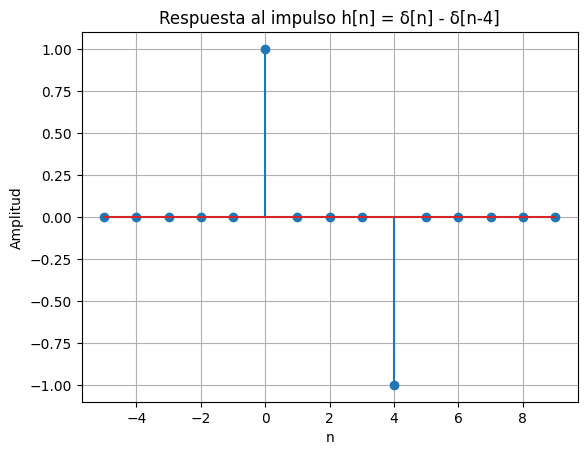

In [10]:
import numpy as np
import matplotlib.pyplot as plt

n = np.arange(-5, 10)

def delta(n):
    return (n == 0).astype(float)

# sistema
h = delta(n) - delta(n-4)

plt.stem(n, h)
plt.title("Respuesta al impulso h[n] = δ[n] - δ[n-4]")
plt.xlabel ("n")
plt.ylabel ("Amplitud")
plt.grid()
plt.show()

Al restar dos cosenos de igual frecuencia pero desplazados en el tiempo, se obtiene otra señal cosenoidal con distinta amplitud y fase.

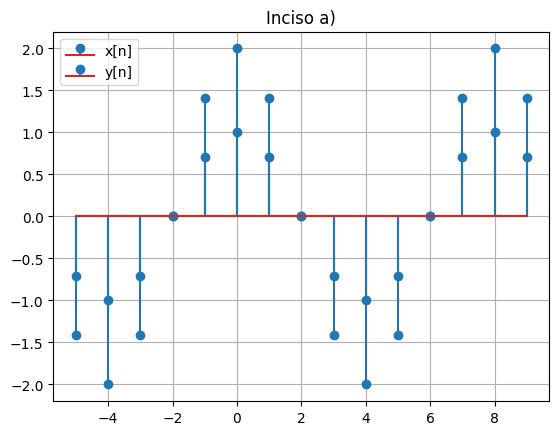

In [11]:
fs = 8000
f0 = 1000
Ts = 1/fs

x = np.cos(2*np.pi*f0*n*Ts)
x_shift = np.cos(2*np.pi*f0*(n-4)*Ts)

y = x - x_shift

plt.stem(n, x)
plt.stem(n, y)
plt.title("Inciso a)")
plt.legend(["x[n]", "y[n]"])
plt.grid()
plt.show()

Se observa que la señal de salida mantiene la misma frecuencia que la entrada, pero presenta una modificación en su amplitud y fase.

Esto se debe a la interferencia entre la señal original y su versión desplazada.

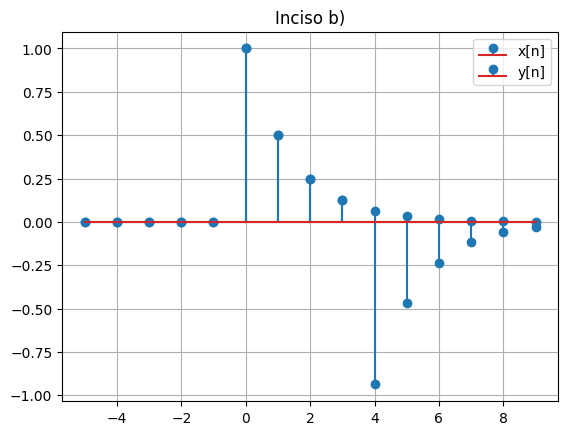

In [12]:
x = (0.5**n) * (n >= 0)
x_shift = (0.5**(n-4)) * (n >= 4)

y = x - x_shift
plt.stem(n, x)
plt.stem(n, y)
plt.title("Inciso b)")
plt.legend(["x[n]", "y[n]"])
plt.grid()
plt.show()

Se observa una señal decreciente que, a partir de cierto punto, presenta valores negativos debido a la resta de la señal desplazada.

Esto refleja el efecto del sistema sobre señales no periódicas.

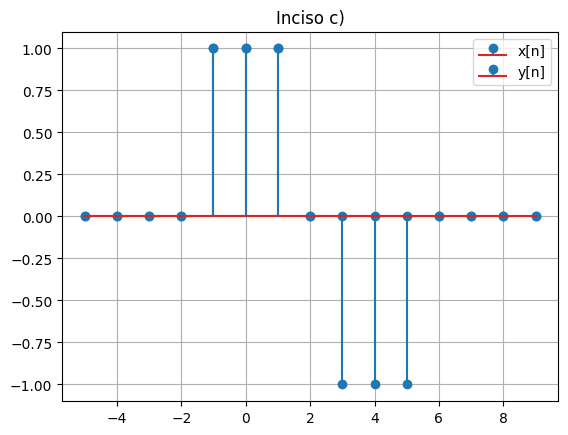

In [13]:
x = (n >= -1).astype(float) - (n >= 2).astype(float)
x_shift = (n >= 3).astype(float) - (n >= 6).astype(float)

y = x - x_shift

plt.stem(n, x)
plt.stem(n, y)
plt.title("Inciso c)")
plt.legend(["x[n]", "y[n]"])
plt.grid()
plt.show()

Se observa que la señal de salida presenta dos regiones: 

Un pulso positivo corresspondiente a la señal original.

Un pulso negativo desplazado 4 muestras. 

Esto es consistente con la operación de resta entre ambas señales.

### Conclusión 
El sistema definido por h [n] = δ[n] - δ[n-4] actúa como un operador de diferencia.

Se observó que:

En señales periódicas, modifica amplitud y fase.

En señales exponenciales, introduce cambios de signo.

En señales por tramos, genera copias desplazadas con signos opuestos.

Esto permite interpretar al sistema como un filtro que resalta cambios en la señal.